***Customer Churn Analysis***

This project analyzes telecom customer churn data to identify factors
that influence customer retention and churn behavior.

***Problem Statement***


Customer churn occurs when customers stop using a company's service.
Understanding churn patterns helps businesses improve customer retention.

Goal of this analysis:
- Identify churn patterns
- Understand key factors influencing churn
- Provide insights to reduce churn

***Analysis*** 

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\vsaro\Customer churn analysis\dataset\churn_data.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [18]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

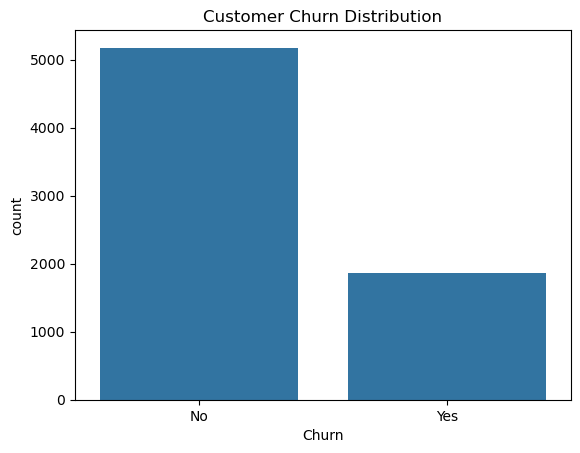

In [33]:
sns.countplot(x='Churn',data=df)
plt.title("Customer Churn Distribution")
plt.show()

***Insights:Customer Churn Distribution***

- Most customers stays
- Some customers leave

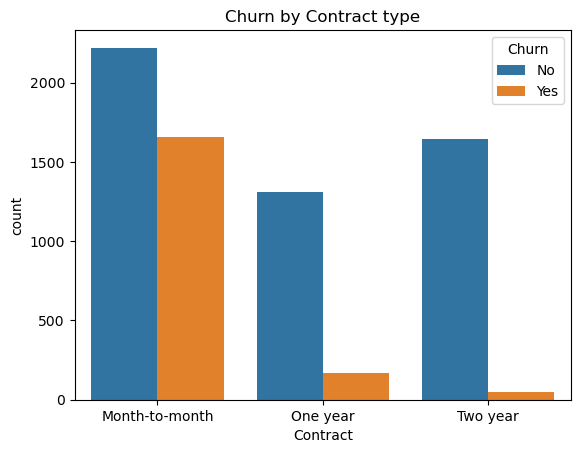

In [34]:
sns.countplot(x='Contract',hue='Churn', data=df)
plt.title("Churn by Contract type")
plt.show()



***Insights:Churn by Contract type***

- Customers who have month to month contract tend to churn more.
- Customers with 1 year contract churn less.


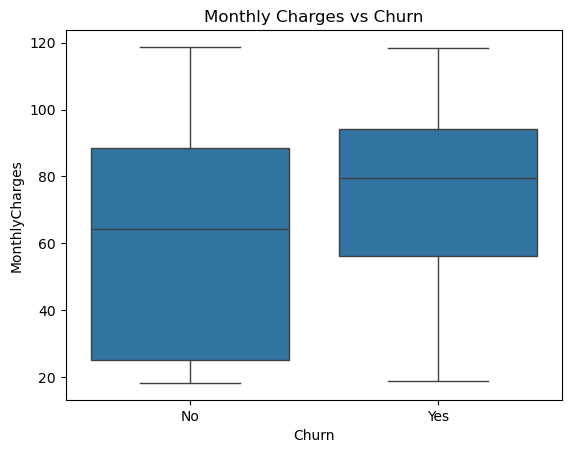

In [35]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

***Insights***
- Customers with higher monthly charges show significantly higher churn.
- This suggests pricing may be a major factor influencing customer retention.

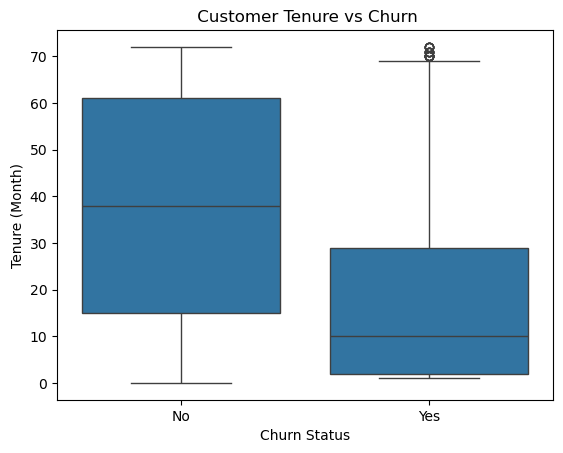

In [39]:
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title(" Customer Tenure vs Churn")
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Month)')
plt.show()

### Insights

- Customers with shorter tenure are more likely to churn.
- Customers who stay longer with the company tend to remain loyal.
- This indicates that churn risk is highest during the early customer lifecycle.
- Improving early customer engagement may help reduce churn.

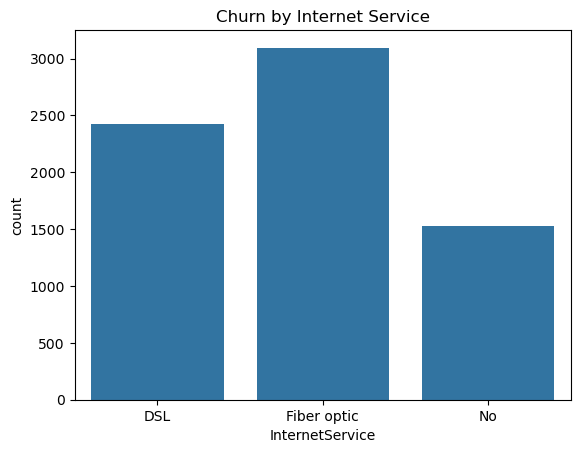

In [41]:
sns.countplot(x='InternetService',data=df)
plt.title("Churn by Internet Service")
plt.show()

### Insight

- Fibre optic customers show higher churn compared to others

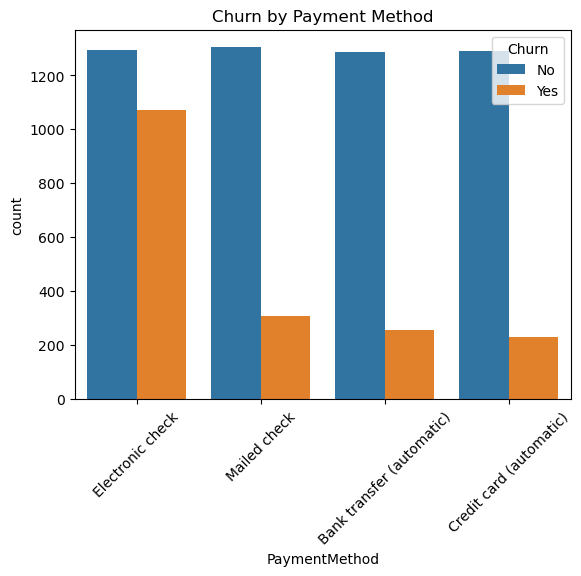

In [43]:
sns.countplot(x='PaymentMethod',hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

### Insight
- Customers with payment method as Electronic check churn more.

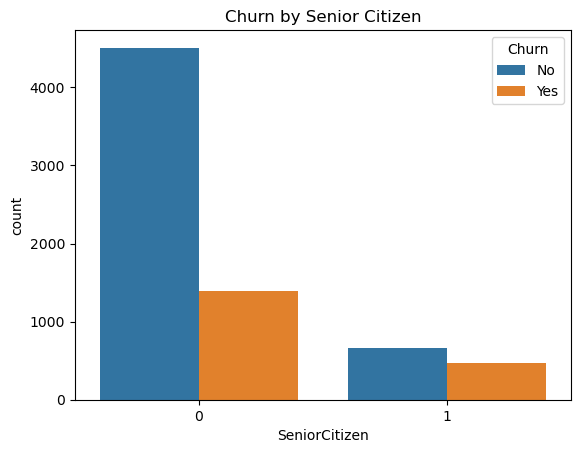

In [46]:
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.title("Churn by Senior Citizen")
plt.show()

### Insight

-  It indicates Senior citizen stay with the company.

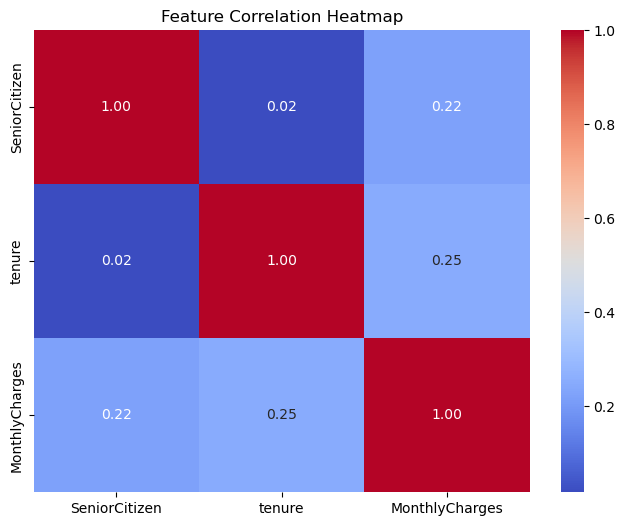

In [4]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Insights

- Tenure and MonthlyCharges show a weak positive correlation (0.25), indicating customers who stay longer tend to pay slightly higher monthly charges.
- SeniorCitizen has almost no correlation with tenure (0.02), suggesting age group does not strongly influence how long customers stay.
- Overall, the numerical features show weak correlations, indicating churn behavior may depend more on categorical factors like contract type and internet service.

### Conclusion

- Customers with month-to-month contracts have the highest churn rate.
- Customers with shorter tenure are more likely to leave the service.
- Higher monthly charges are associated with increased churn.
- Long-term contracts and better early customer engagement could help reduce churn.